# K-Nearest-Neighbors

👇 `data` klasöründe bulunan `houses_clean.csv` dataset'ini yükleyin  
Veya doğrudan bu URL'den yükleyebilirsiniz: [https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv](https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv).  

Dataset açıklaması dataset-description.md dosyasında bulunabilir.

In [1]:
# YOUR CODE HERE
import pandas as pd
df = pd.read_csv("/Users/gonul/workintech_project/S16D1-S-data-knn/data/ML_Houses_clean.csv")
df.describe

<bound method NDFrame.describe of       GrLivArea  BedroomAbvGr  KitchenAbvGr  OverallCond  CentralAir  \
0      0.380070         0.375      0.333333        0.500           1   
1     -0.312090         0.375      0.333333        0.875           1   
2      0.497489         0.375      0.333333        0.500           1   
3      0.390885         0.375      0.333333        0.500           1   
4      1.134029         0.500      0.333333        0.500           1   
...         ...           ...           ...          ...         ...   
1455   0.282735         0.375      0.333333        0.500           1   
1456   0.940904         0.375      0.333333        0.625           1   
1457   1.353418         0.500      0.333333        1.000           1   
1458  -0.596369         0.250      0.333333        0.625           1   
1459  -0.321360         0.375      0.333333        0.625           1   

      SalePrice  
0        208500  
1        181500  
2        223500  
3        140000  
4        25

💡 Çoğu özellik zaten önceden işlenmiştir (normalizasyonla ölçeklendirilmiştir), tıpkı Veri Hazırlama gününde yaptığınız gibi  

💡 Bir özellik olan `GrLiveArea` normalleştirilmemiştir. Daha sonra normalizasyonunun model performansımız üzerindeki etkisini görmek için bu şekilde tutuyoruz  

👇 Bunu tanımlayıcı istatistiklerle kolayca görebilirsiniz, min ve max değerlerine bakın

In [7]:
df.describe()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,0.078410,0.358305,0.348858,0.571918,0.934932,180921.195890
std,0.813952,0.101972,0.073446,0.139100,0.246731,79442.502883
min,-2.263422,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,-0.516802,0.250000,0.333333,0.500000,1.000000,129975.000000
50%,0.000000,0.375000,0.333333,0.500000,1.000000,163000.000000
75%,0.483198,0.375000,0.333333,0.625000,1.000000,214000.000000
max,6.455002,1.000000,1.000000,1.000000,1.000000,755000.000000


In [10]:
df.columns

Index(['GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'OverallCond',
       'CentralAir', 'SalePrice'],
      dtype='object')

# Varsayılan KNN

🎯 Görev, tüm özelliklerle evlerin fiyatını (`SalePrice`) tahmin etmektir.

👇 Böyle bir görevde varsayılan [KNNRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)'ı değerlendirmek için çapraz doğrulama kullanın.  
❓ `SalePrice`'taki varyansın özellikler tarafından açıklanan oranı nedir?  
Cevabınızı `base_knn_score` adlı bir değişkende saklayın.

<details>
<summary> 💡 İpucu </summary>
    <br>
    ℹ️ Bağımlı değişkendeki varyansın bağımsız değişkenler tarafından açıklanan oranı R2 skoru'dur.
</details>

In [13]:
# YOUR CODE HERE
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


X = df[['GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'OverallCond', 'CentralAir']].copy()
y = df['SalePrice']

X['CentralAir'] = X['CentralAir'].map({'Y':1, 'N':0})
model = make_pipeline(
    SimpleImputer(strategy='median'),  # NaN doldur
    StandardScaler(),
    KNeighborsRegressor()
)
base_knn_score = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
).mean()
print(base_knn_score);


0.6313828688153149


/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['CentralAir']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['CentralAir']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['CentralAir']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['CentralAir']. At least one 

### 🧪 Kodunuzu kontrol edin

In [14]:
from nbresult import ChallengeResult

result = ChallengeResult('default_score',
                         score = base_knn_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S16D1-S-data-knn/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_default_score.py::TestDefaultScore::test_default_score PASSED       [100%]

============================== 1 passed in 0.07s ===============================


💯 You can commit your code:

git add tests/default_score.pickle

git commit -m 'Completed default_score step'

git push origin master



# Ölçek duyarlılığı

KNN'ler ve mesafe tabanlı algoritmalar özelliklerin ölçeğine son derece duyarlı olabilir. 

👇 Özellik kümesini **tam ortak aralık** içinde yeniden ölçeklendirin ve `X_rescaled` adlı bir değişken altında kaydedin  
Ardından, yeniden ölçeklendirilmiş özellikler üzerinde bir modeli değerlendirin ve skorunu `rescaled_score` değişken adı altında kaydedin.

<details>
<summary> 💡 İpucu </summary>
    
`MinMaxScaler()`

Sadece `GrLiveArea`'nın normalleştirilmesi gerekmesine rağmen, tüm özelliklerinizde MinMaxScaler kullanmak sorun değil  
    
Gerçekten de, Min-Max Ölçeklendirme [idempotent](https://en.wikipedia.org/wiki/Idempotence) bir dönüşümdür: eğer $X_{max}=1$ ve $X_{min}=0$ ise, o zaman $X = \frac{X - X_{min}}{X_{max} - X_{min}}$
</details>

In [16]:
# YOUR CODE HERE
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


X = df[['GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'OverallCond', 'CentralAir']].copy()
y = df['SalePrice']

X['CentralAir'] = X['CentralAir'].map({'Y':1, 'N':0})
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)
scaler = MinMaxScaler()
X_rescaled = scaler.fit_transform(X_imputed)

rescaled_score = cross_val_score(
    KNeighborsRegressor(),
    X_rescaled,
    y,
    cv=5,
    scoring='r2'
).mean()

print(rescaled_score)

0.6357490406255442


/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['CentralAir']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


👉 R2 skoru artmış olmalı!

💡 Mesafe tabanlı algoritmaları modellerken özelliklerin tam ortak aralıkta olması tercih edilir.  
Ancak, her zaman daha iyi bir skor garanti etmez.  
Bu bir deneme yanılma sürecidir.

### 🧪 Kodunuzu kontrol edin

In [17]:
from nbresult import ChallengeResult

result = ChallengeResult('scale_sensitivity',
                         base_score = base_knn_score,
                         rescaled_features = X_rescaled,
                         rescaled_score = rescaled_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S16D1-S-data-knn/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_scale_sensitivity.py::TestScaleSensitivity::test_base_score PASSED  [ 33%]
test_scale_sensitivity.py::TestScaleSensitivity::test_rescaled_features PASSED [ 66%]
test_scale_sensitivity.py::TestScaleSensitivity::test_score_inscrease PASSED [100%]

============================== 3 passed in 0.08s ===============================


💯 You can commit your code:

git add tests/scale_sensitivity.pickle

git commit -m 'Completed scale_sensitivity step'

git push origin master



# $k$ Optimizasyonu

👇 Yeniden ölçeklendirilmiş özellikler üzerinde bir KNNRegressor'ın K parametresini (`n_neighbors` parametresini kullanarak) ince ayarlayın. K 1'den 25'e kadar arttıkça skorun evrimini çizin.

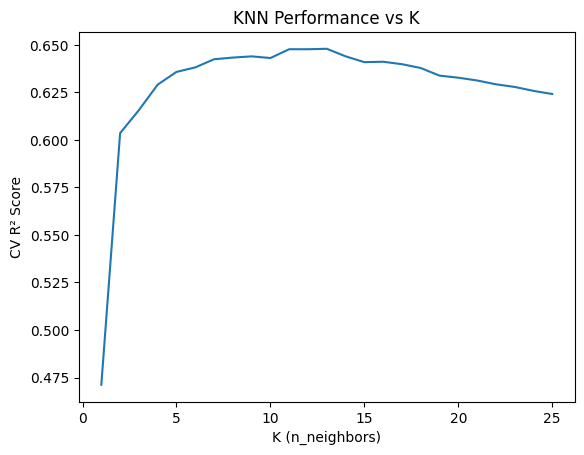

In [19]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

k_values = range(1,26)
scores = []
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)

    score = cross_val_score(
        model,
        X_rescaled,   # önceki adımda oluşturduğun ölçeklenmiş veri
        y,
        cv=5,
        scoring='r2'
    ).mean()

    scores.append(score)
plt.plot(k_values, scores)
plt.xlabel("K (n_neighbors)")
plt.ylabel("CV R² Score")
plt.title("KNN Performance vs K")
plt.show()


❓ K'nın hangi değeri en iyi performansı üretir? Cevabınızı `best_k` değişken adı altında kaydedin.

In [22]:
# YOUR CODE HERE
best_k = 11

<details>
<summary> 👉 Çözüm 👈</summary>
    
Grafiğinize bakarak, skorun k = 5 civarında artmayı durdurduğunu ve maksimum skorun k = 11 için ulaşıldığını görmelisiniz.

</details>

❓ $k$ < 5 değerleri için modelin kötü performansını nasıl yorumluyorsunuz?

<details>
<summary> 👉 Çözüm 👈</summary>
    
K çok küçük olduğunda, model eğitim kümesine aşırı uyum gösterme eğiliminde olacaktır. İyi genelleştirebilmek için çok az noktaya odaklanacaktır. K'yı artırmak modele tahminlerini dayandıracağı daha fazla örnek verecektir.

</details>

### 🧪 Kodunuzu kontrol edin

In [24]:
from nbresult import ChallengeResult

result = ChallengeResult('optimal_k',
                         optimal_k = best_k)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S16D1-S-data-knn/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_optimal_k.py::TestOptimal_k::test_optimal_k PASSED                  [100%]

============================== 1 passed in 0.00s ===============================


💯 You can commit your code:

git add tests/optimal_k.pickle

git commit -m 'Completed optimal_k step'

git push origin master



# KNN'de Aşırı Uyum

💡 KNN'lerin K parametresi çok küçük olduğunda, eğitim kümesine aşırı uyum gösterme ve iyi genelleştirememe riski vardır. 

👇 K=2 parametreli bir KNN'in öğrenme eğrilerini çizin.

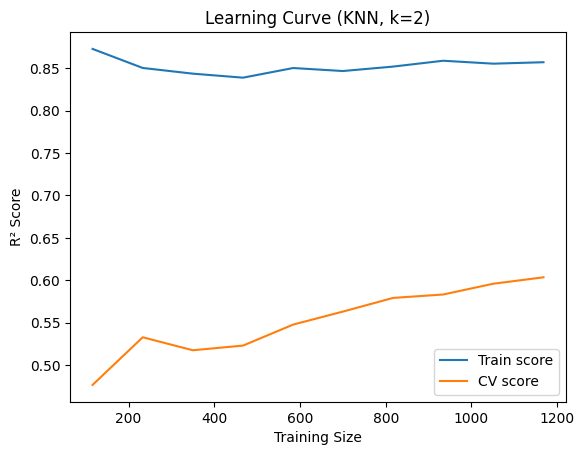

In [28]:
# YOUR CODE HERE
import numpy as np
from sklearn.model_selection import learning_curve

k_value = 2
model = KNeighborsRegressor(n_neighbors=k_value)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_rescaled,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train score")
plt.plot(train_sizes, test_mean, label="CV score")
plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.title("Learning Curve (KNN, k=2)")
plt.legend()
plt.show()


👉 Yüksek eğitim skoru ama düşük test skoru gözlemlemelisiniz. ⚠️ Aşırı uyum uyarısı ⚠️ Bu çok düşük K parametresinden kaynaklanır.

# İdeal K

👇 Bu sefer, "$k$ Optimizasyonu" bölümünde bulduğunuz ideal K değeri için öğrenme eğrilerini çizin.

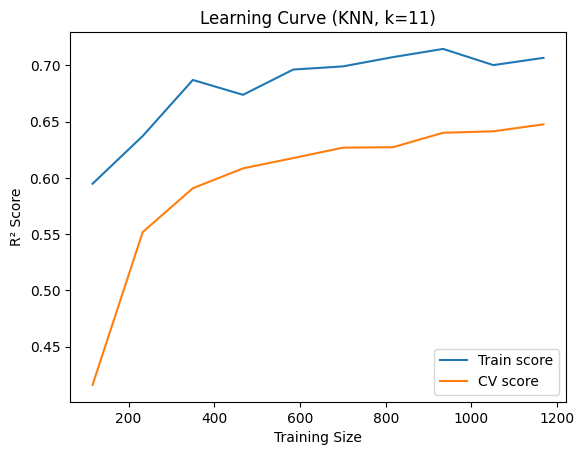

In [29]:
# YOUR CODE HERE
model = KNeighborsRegressor(n_neighbors=best_k)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_rescaled,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train score")
plt.plot(train_sizes, test_mean, label="CV score")

plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.title(f"Learning Curve (KNN, k={best_k})")
plt.legend()
plt.show()

👉 Eğriler yakınsamaya yakın olmalı, bu da modelin daha az aşırı uyum gösterdiğini ve daha iyi genelleştirdiğini gösterir.

💡 KNN modelleriyle modelleme yaparken hatırlanması gereken iki temel unsur vardır:  
    1. Mesafe tabanlı algoritmalar özelliklerin ölçeğine son derece duyarlıdır  
    2. K ayarlanmalıdır: performans, genelleştirme ve aşırı uyum arasındaki dengeyi kontrol eder

❓ Optimize edilmiş KNN modelinin gerçek fiyat ile tahmin edilen fiyat arasındaki ortalama fark nedir? Cevabınızı hesaplayın ve `price_error` değişken adı altında kaydedin

<details>
<summary> 💡 İpucu </summary>
    
Hesaplamanız gereken metrik **Negatif Ortalama Mutlak Hata (MAE)**'dır.

</details>

In [33]:
# YOUR CODE HERE
from sklearn.model_selection import cross_val_predict

knn_model = KNeighborsRegressor(n_neighbors=best_k)

# cross-validated predictions
y_pred = cross_val_predict(
    knn_model,
    X_rescaled,
    y,
    cv=5
)

# Ortalama mutlak hata
price_error = np.mean(np.abs(y - y_pred))

print(price_error)

knn_score = cross_val_score(
    knn_model,
    X_rescaled,
    y,
    cv=5,
    scoring='r2'
).mean()
knn_score

31341.70386052304


0.6476811896475059

### 🧪 Kodunuzu kontrol edin

In [34]:
from nbresult import ChallengeResult

result = ChallengeResult('price_error',
                         error = price_error)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S16D1-S-data-knn/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_price_error.py::TestPriceError::test_price_error PASSED             [100%]

============================== 1 passed in 0.06s ===============================


💯 You can commit your code:

git add tests/price_error.pickle

git commit -m 'Completed price_error step'

git push origin master



# Model Seçimi

❓ Ev fiyatlarını tahmin etme görevini gerçekleştirmek için bu iki modelden hangisini seçersiniz:
- Az önce ayarladığınız KNN modeli
- Bir Linear Regression modeli

Cevabınızı "KNN" veya "LinearReg" olarak `best_model` değişken adı altında string olarak kaydedin.

<details>
<summary> 💡 İpucu </summary>
    
Hangisini seçeceğinize karar vermek için, aynı görev üzerinde bir Linear Regression skorunu değerlendirmeniz ve KNN'in skoruyla karşılaştırmanız gerekecek. Aynı metrikleri karşılaştırdığınızdan emin olun!!

</details>

In [35]:
# YOUR CODE HERE

from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()

lin_score = cross_val_score(
    lin_model,
    X_rescaled,
    y,
    cv=5,
    scoring='r2'
).mean()

best_model = "KNN" if knn_score > lin_score else "LinearReg"

print("KNN:", knn_score)
print("Linear:", lin_score)
print("Best model:", best_model)

KNN: 0.6476811896475059
Linear: 0.5747280262334963
Best model: KNN


💡 Her iki modelin metriklerini karşılaştırdığınızda, KNN modeli Linear Regression'ı geçmelidir. Bu, verideki doğrusal olmayan kalıpları yakalama yeteneğinden kaynaklanabilir.

### 🧪 Kodunuzu kontrol edin

In [36]:
from nbresult import ChallengeResult

result = ChallengeResult('best_model',
                         model = best_model)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S16D1-S-data-knn/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_best_model.py::TestBestModel::test_best_model PASSED                [100%]

============================== 1 passed in 0.00s ===============================


💯 You can commit your code:

git add tests/best_model.pickle

git commit -m 'Completed best_model step'

git push origin master



# 🏁